In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../")

In [7]:
full_f = np.load("results/PassiveWalker-v0/EA_4/full_f.npy")
full_x = np.load("results/PassiveWalker-v0/EA_4/full_x.npy")

In [8]:
full_f

array([[        -inf,         -inf,         -inf, ..., -15.75022901,
                -inf,         -inf],
       [        -inf,         -inf,         -inf, ...,         -inf,
                -inf,         -inf],
       [        -inf,         -inf,  32.56560073, ...,  -6.63549571,
                -inf,         -inf],
       ...,
       [-94.22102488, -23.24734725, -15.42527559, ...,         -inf,
                -inf, -32.3055044 ],
       [-22.38692217,         -inf, -68.71377691, ..., -10.31086729,
        -16.85741784, 154.19113565],
       [-42.79541813,  21.79475657,  84.13212665, ..., -35.25042631,
                -inf,         -inf]])

(-0.1, 1001.0)

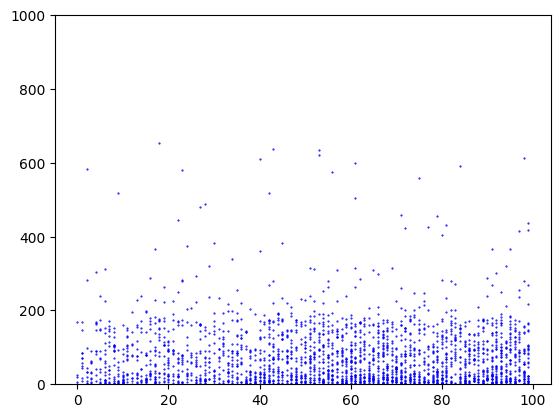

In [9]:
plt.plot(full_f, ".b", markersize=1)
plt.ylim([-0.1,1001])

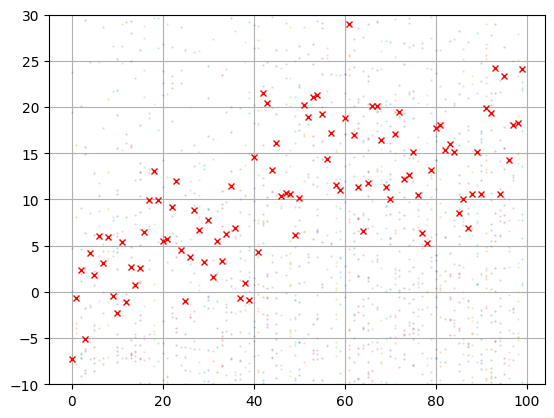

In [30]:
for i in range(100):
    plt.plot(i*np.ones(100),full_f[i], ".", markersize=1, alpha=0.3)
    plt.plot(i,np.mean(np.clip(full_f[i], -10,100000)), "x", color="red", markersize=5)
plt.ylim([-10,30])
plt.grid("on")

(-0.1, 60.0)

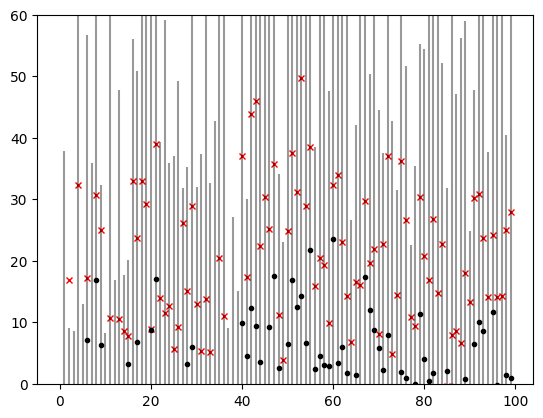

In [23]:
for i in range(full_f.shape[0]):
    vals = full_f[i]
    finite = np.isfinite(vals)          # removes -inf, +inf, nan
    # also remove values of -1000 (which is the default value for uninitialized entries)
    finite &= (vals > -999)
    v = vals[finite]

    # plt.plot(i*np.ones_like(vals), vals, ".", markersize=1, alpha=0.25)

    if v.size > 0:
        mu = v.mean(axis=0)                   # finite mean
        med = np.median(v, axis=0)              # robust center
        q25, q75 = np.quantile(v, [0.25, 0.75], axis=0)

        plt.plot(i, mu, "x", color="red", markersize=5)      # mean (finite only)
        plt.plot(i, med, "o", color="black", markersize=3)   # median
        plt.vlines(i, q25, q75, color="black", alpha=0.4)    # IQR
plt.ylim([-0.1,60])

In [13]:
full_x[-1,-1]

array([0.5       , 0.5       , 0.5       , 0.5       , 0.26859011,
       0.1300598 ])

In [27]:
np.argmax(full_f[73])

np.int64(12)

In [28]:
full_x[73,12,:]

array([0.09481275, 0.34998705, 0.40082637, 0.5       , 0.17754931,
       0.5       ])

In [18]:
full_f.shape, full_x.shape

((100, 100), (100, 100, 6))